In [1]:
import surf as surf
import surf_analysis as surfA
import surf_inputs as surfIN
import surf_insitu as surfIS

import numpy as np
import os
import astropy.units as u
import pandas as pd
from datetime import datetime, timedelta
from astropy.time import Time
import re
from sunpy.coordinates import sun
import helio_coords as hcoords

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

# Function to get earth's latitude
def get_earth_lat(dt):
    """
    A function to return Earth latitude for a given date, in radians
 
    Parameters
    ----------
    dt : datetime
 
    Returns
    -------
    E_lat: Earth latitude, with astropy units of radians
 
    """
    cr, cr_lon_init = surfIN.datetime2surfinputs(dt)
    
    # Use the HUXt ephemeris data to get Earth lat over the CR
    # ========================================================
    dummymodel = surf.SURF(v_boundary=np.ones(128)*400*(u.km/u.s), simtime=0.1*u.day,
                         cr_num=cr,cr_lon_init=cr_lon_init, lon_out=0.0*u.deg)
    # retrieve a bodies position at each model timestep:
    earth = dummymodel.get_observer('earth')
    # get average Earth lat
    E_lat = np.nanmean(earth.lat_c)
    E_lat = E_lat.to(u.deg)  # Convert to degrees
    return E_lat

def earth_R(mjd):
    #returns the heliocentric distance of Earth (in km). Based on Franz+Harper2002
    AU = 149597870.691
    
    #first up, switch to JD.
    JD=mjd+2400000.5
    d0=JD-2451545
    T0=d0/36525


    L2=100.4664568 + 35999.3728565*T0
    g2=L2-(102.9373481+0.3225654*T0)
    g2=g2*np.pi/180 #mean anomaly

    rAU=1.00014 - 0.01671*np.cos(g2)-0.00014*np.cos(2*g2);
    R=rAU*AU
    
    return R

In [3]:
# Read in Met Office Cone CME files
project_dirs = surf._setup_dirs_()
crpath = os.path.join(project_dirs['input'],'(I)CMEs.csv')

# Load the CSV file into a DataFrame
crlist = pd.read_csv(crpath)

# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# compute 21.5-215 transit time
#crlist['tt_21'] = np.nan 
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_21'] = crlist['tt_21'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

# Add a new column with carrington rotation number of CME time
crlist['cr_num'] = crlist['Time_21.5'].apply(lambda dt: surfIN.datetime2surfinputs(dt)[0])
crlist['cr_lon_init'] = crlist['Time_21.5'].apply(lambda dt: surfIN.datetime2surfinputs(dt)[1])
crlist['earth_lat'] = crlist['Time_21.5'].apply(lambda dt: get_earth_lat(dt))

In [4]:
crlist.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Time_21.5         32 non-null     datetime64[us]
 1   Disturbance_Time  32 non-null     datetime64[us]
 2   CME_V             32 non-null     int64         
 3   lon               32 non-null     int64         
 4   lat               32 non-null     int64         
 5   Ang_rad           32 non-null     int64         
 6   V_max             32 non-null     float64       
 7   V_max_smooth      32 non-null     float64       
 8   tt_21             32 non-null     float64       
 9   cr_num            32 non-null     int64         
 10  cr_lon_init       32 non-null     object        
 11  earth_lat         32 non-null     object        
dtypes: datetime64[us](2), float64(3), int64(5), object(2)
memory usage: 3.1+ KB


In [5]:
onecme = crlist.iloc[5,:]

ftime = onecme['Time_21.5']
cr, cr_lon_init = surfIN.datetime2surfinputs(ftime)

cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=21.5*u.solRad, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=11.5 * 60 * 60 * u.s)

bg_model = surfIS.omniSURF_reconstruction(ftime, ftime +timedelta(days=27), 
                        rmin=21.5*u.solRad, rmax=250*u.solRad, 
                        dt_scale=4, dt=1*u.day,
                        run_2d=False,
                        solver='huxt')

model = surfIS.omniSURF_reconstruction(ftime, ftime +timedelta(days=27), 
                        rmin=21.5*u.solRad, rmax=250*u.solRad, 
                        dt_scale=4, dt=1*u.day,
                        run_2d=False,
                        solver='huxt')

bg_model.solve([])
model.solve([cme])

Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


Single longitude simulated. Extracting time series at Observer r
Single longitude simulated. Extracting time series at Observer r


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

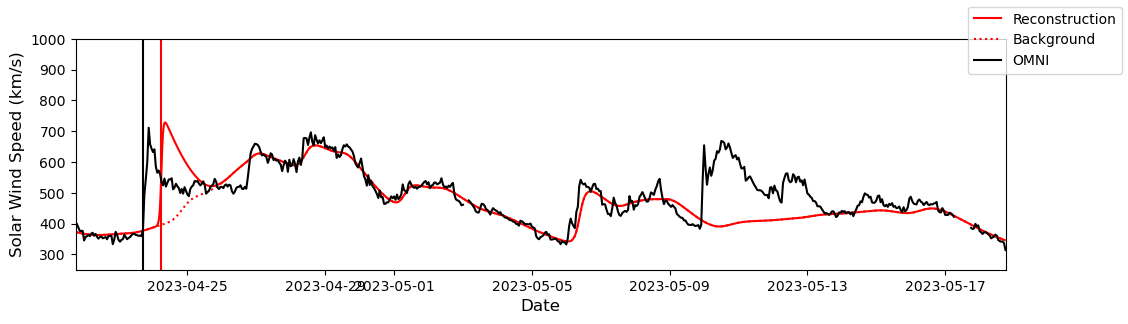

In [23]:
def plot_earth_timeseries(model, bg_model, ax=None, plot_omni=True):
    """
    A function to plot the HUXt Earth time series. With option to download and plot OMNI data.
    Args:
        model : input model class
        plot_omni: Boolean, if True downloads and plots OMNI data

    Returns:
        fig : Figure handle
        axs : Axes handles

    """

    fig, ax = plt.subplots(figsize=(12, 3))
        
    ts = surfA.get_observer_timeseries(model, observer='Earth')
    bg_ts = surfA.get_observer_timeseries(bg_model, observer='Earth')
    
    cme_out = model.cmes[0]
    stats = cme_out.compute_arrival_at_body('EARTH')
    
    hit = stats['hit']
    
    if hit == 1:
        t_arrive = stats['t_arrive'].value
        t_arrive = Time(t_arrive, format='jd', scale='utc')

    ax.plot(ts['time'], ts['vsw'], 'r', label='Reconstruction')
    ax.plot(bg_ts['time'], bg_ts['vsw'], 'r', linestyle='dotted', label='Background')
    
    if hit == 1:
        ax.axvline(t_arrive.datetime,color='r')
        
    ax.set_ylim(250, 1000)

    starttime = onecme['Time_21.5']
    endtime = onecme['Time_21.5'] + timedelta(days=27.0)

    if plot_omni:
        # grab the omni data
        data = surfIS.get_omni(starttime, endtime)
        # plot the period of interest
        mask = (data['datetime'] >= starttime) & (data['datetime'] <= endtime)
        plotdata = data[mask]
        ax.plot(plotdata['datetime'], plotdata['V'], 'k', label='OMNI')

    ax.set_xlim(starttime, endtime)

    ax.set_ylabel('Solar Wind Speed (km/s)',fontsize=12)
    ax.set_xlabel('Date',fontsize=12)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    ax.axvline(onecme['Disturbance_Time'], color='k')

    fig.legend(fontsize=10)

    return fig, ax

def plot_time_series():

    fig, ax = plot_earth_timeseries(model, bg_model, plot_omni=True)
    
    fig.savefig("/Users/dven/repos/CME_pulse_duration/surf/figures/1.pdf", dpi=300,bbox_inches='tight')

plot_time_series()

Single longitude simulated. Extracting time series at Observer r


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: ylabel='V [km/s]'>,
        <Axes: xlabel='Date', ylabel='B$_{\\text{POL}}$'>], dtype=object))

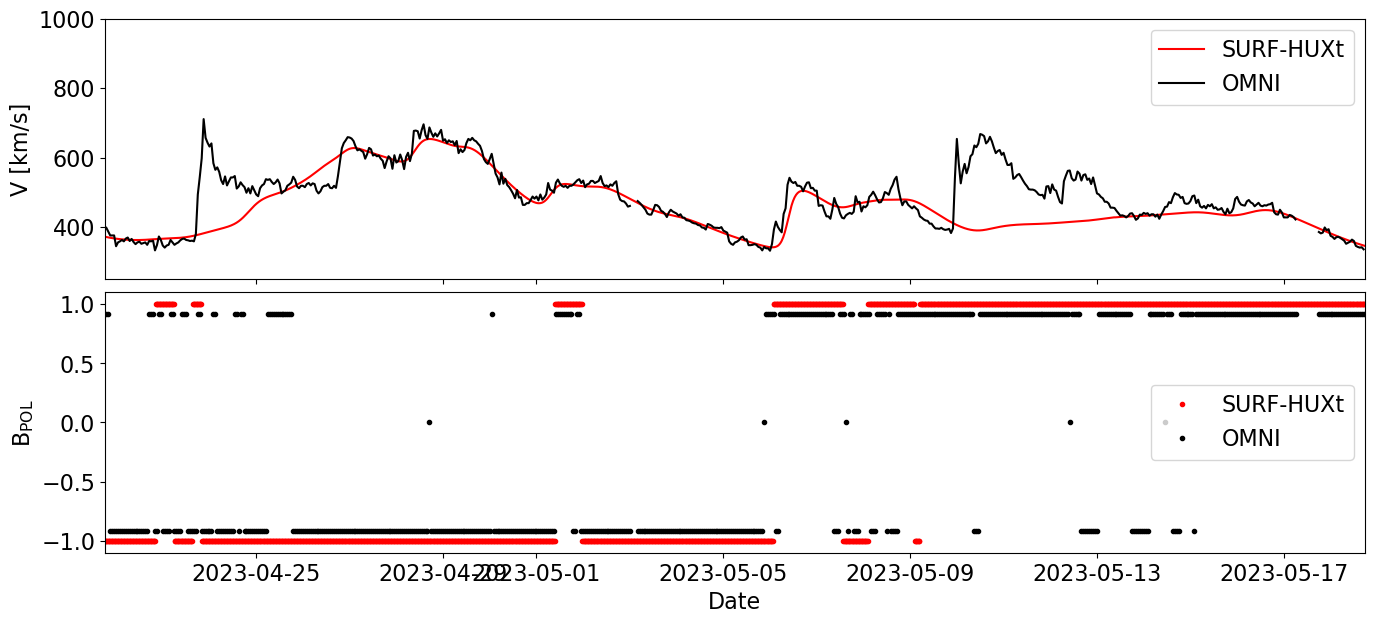

In [30]:
surfA.plot_earth_timeseries(bg_model,plot_omni=True)